In [1]:
import yfinance as yf
import pandas as pd

# 3 US + 3 UK stocks across tech, banking, energy and consumer goods
tickers = ["AAPL", "MSFT", "JPM", "HSBA.L", "BP.L", "ULVR.L"]

prices = yf.download(tickers, start="2021-01-01", end="2026-09-30",
                     auto_adjust=True)["Close"]

print(prices.shape)
prices.tail()

[*********************100%***********************]  6 of 6 completed

(1478, 6)


Ticker,AAPL,BP.L,HSBA.L,JPM,MSFT,ULVR.L
Date,,,,,,
2026-09-23,337.019989,557.200012,1514.599976,335.854431,500.589996,4677.0
2026-09-24,335.920013,571.799988,1499.800049,336.879333,497.929993,4708.5
2026-09-25,341.070007,558.500000,1512.199951,341.356995,516.169983,4664.5
2026-09-28,338.399994,563.500000,1516.400024,334.919098,509.220001,4671.0
2026-09-29,329.399994,550.700012,1510.000000,333.317108,508.959991,4615.5


In [2]:
print("Shape:", prices.shape)
print("\nMissing values per stock:")
print(prices.isna().sum())
print("\nFirst date:", prices.index.min().date(), "| Last date:", prices.index.max().date())

Shape: (1478, 6)

Missing values per stock:
Ticker
AAPL      37
BP.L      30
HSBA.L    30
JPM       37
MSFT      37
ULVR.L    29
dtype: int64

First date: 2021-01-04 | Last date: 2026-09-29


In [3]:
# Keep only days when both US and UK markets were open
clean_prices = prices.dropna()
print("Days before:", len(prices), "| Days after:", len(clean_prices))

# Daily % returns
returns = clean_prices.pct_change().dropna()

print("\nAverage daily return (%):")
print((returns.mean() * 100).round(3))
returns.head()

Days before: 1478 | Days after: 1410

Average daily return (%):
Ticker
AAPL      0.084
BP.L      0.072
HSBA.L    0.111
JPM       0.091
MSFT      0.079
ULVR.L    0.005
dtype: float64


Ticker,AAPL,BP.L,HSBA.L,JPM,MSFT,ULVR.L
Date,,,,,,
2021-01-05,0.012364,0.070727,-0.004601,0.005442,0.000965,-0.005604
2021-01-06,-0.033662,0.063486,0.099181,0.046956,-0.025929,0.006988
2021-01-07,0.034124,0.017943,0.002163,0.032839,0.028457,-0.004477
2021-01-08,0.008631,0.012542,-0.012708,0.001104,0.006093,0.000675
2021-01-11,-0.023249,0.000335,-0.008622,0.014924,-0.009698,-0.007641


In [4]:
import numpy as np

summary = pd.DataFrame({
    "Annual return (%)": returns.mean() * 252 * 100,
    "Annual volatility (%)": returns.std() * np.sqrt(252) * 100,
})
summary["Return per unit of risk"] = summary["Annual return (%)"] / summary["Annual volatility (%)"]

summary.round(2).sort_values("Return per unit of risk", ascending=False)

,Annual return (%),Annual volatility (%),Return per unit of risk
Ticker,,,
HSBA.L,27.99,25.52,1.10
JPM,23.05,24.35,0.95
AAPL,21.12,27.89,0.76
MSFT,19.84,27.63,0.72
BP.L,18.23,29.52,0.62
ULVR.L,1.35,19.51,0.07


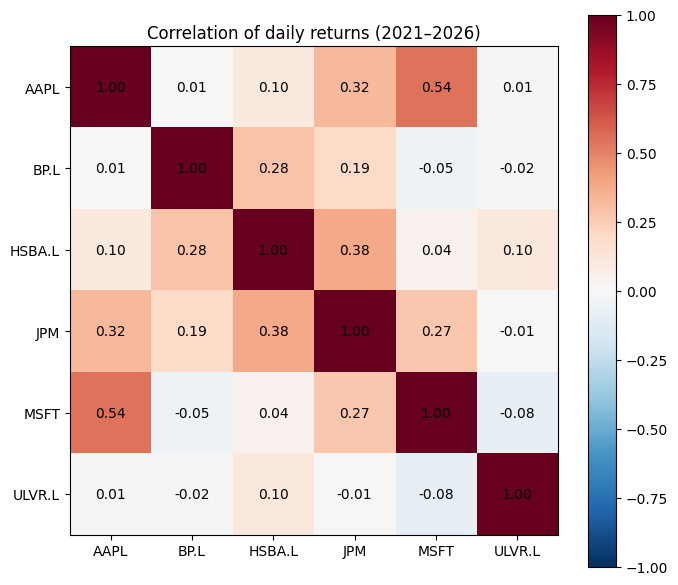

In [5]:
import matplotlib.pyplot as plt

corr = returns.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im)
ax.set_title("Correlation of daily returns (2021–2026)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [6]:
weekly_returns = clean_prices.resample("W").last().pct_change().dropna()
weekly_corr = weekly_returns.corr()

print("Daily vs weekly correlation, US–UK pairs:")
for us in ["AAPL", "MSFT", "JPM"]:
    for uk in ["HSBA.L", "BP.L", "ULVR.L"]:
        print(f"{us} vs {uk}:  daily {corr.loc[us, uk]:.2f}  |  weekly {weekly_corr.loc[us, uk]:.2f}")

Daily vs weekly correlation, US–UK pairs:
AAPL vs HSBA.L:  daily 0.10  |  weekly 0.21
AAPL vs BP.L:  daily 0.01  |  weekly 0.04
AAPL vs ULVR.L:  daily 0.01  |  weekly 0.02
MSFT vs HSBA.L:  daily 0.04  |  weekly 0.02
MSFT vs BP.L:  daily -0.05  |  weekly -0.16
MSFT vs ULVR.L:  daily -0.08  |  weekly -0.03
JPM vs HSBA.L:  daily 0.38  |  weekly 0.44
JPM vs BP.L:  daily 0.19  |  weekly 0.23
JPM vs ULVR.L:  daily -0.01  |  weekly 0.05
